DATA PREPROCESSING

a) Import

In [1]:
import pandas as pd

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260401.csv", low_memory=False)
df.shape

(2252143, 29)

b) Parse

In [2]:
# Parsing: Date & Time
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df[['CRASH DATE', 'CRASH TIME']].head()

,CRASH DATE,CRASH TIME
0,2021-09-11,1900-01-01 02:39:00
1,2022-03-26,1900-01-01 11:45:00
2,2023-11-01,1900-01-01 01:29:00
3,2022-06-29,1900-01-01 06:55:00
4,2022-09-21,1900-01-01 13:21:00


In [3]:
# Parsing: Number columns
num_cols = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED',
    'NUMBER OF MOTORIST KILLED',
    'LATITUDE',
    'LONGITUDE'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[num_cols].head()

,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,LATITUDE,LONGITUDE
0,2.0,0.0,0,0,0,0,2,0,NaN,NaN
1,1.0,0.0,0,0,0,0,1,0,NaN,NaN
2,1.0,0.0,0,0,0,0,1,0,40.62179,-73.970024
3,0.0,0.0,0,0,0,0,0,0,NaN,NaN
4,0.0,0.0,0,0,0,0,0,0,NaN,NaN


In [4]:
df.dtypes[['CRASH DATE', 'CRASH TIME'] + num_cols]

CRASH DATE                       datetime64[ns]
CRASH TIME                       datetime64[ns]
NUMBER OF PERSONS INJURED               float64
NUMBER OF PERSONS KILLED                float64
NUMBER OF PEDESTRIANS INJURED             int64
NUMBER OF PEDESTRIANS KILLED              int64
NUMBER OF CYCLIST INJURED                 int64
NUMBER OF CYCLIST KILLED                  int64
NUMBER OF MOTORIST INJURED                int64
NUMBER OF MOTORIST KILLED                 int64
LATITUDE                                float64
LONGITUDE                               float64
dtype: object

c) Organize

In [5]:
# Organizing
cols_keep = [
    'CRASH DATE',
    'CRASH TIME',
    'BOROUGH',
    'ZIP CODE',
    'LATITUDE',
    'LONGITUDE',
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'CONTRIBUTING FACTOR VEHICLE 1',
    'VEHICLE TYPE CODE 1'
]

crash_df = df[cols_keep].copy()
crash_df = crash_df.dropna(subset=['BOROUGH'])
crash_df['HOUR'] = crash_df['CRASH TIME'].dt.hour
crash_df['MONTH'] = crash_df['CRASH DATE'].dt.month

crash_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,CONTRIBUTING FACTOR VEHICLE 1,VEHICLE TYPE CODE 1,HOUR,MONTH
2,2023-11-01,1900-01-01 01:29:00,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,Unspecified,Moped,1,11
9,2021-09-11,1900-01-01 09:35:00,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,Unspecified,Sedan,9,9
10,2021-12-14,1900-01-01 08:13:00,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,NaN,NaN,8,12
13,2021-12-14,1900-01-01 08:17:00,BRONX,10475,40.868160,-73.831480,2.0,0.0,Unspecified,Sedan,8,12
14,2021-12-14,1900-01-01 21:10:00,BROOKLYN,11207,40.671720,-73.897100,0.0,0.0,Driver Inexperience,Sedan,21,12


In [6]:
crash_df.shape

(1564912, 12)

BASIC DATA EXPLORATION AND SUMMARY STATISTICS 

1) Descriptive Statistics: The dataset contains over 2.25 million crash records and 29 features, making it a large, high dimensional dataset. Most crashes result in zero or few injuries, indicating a highly skewed distribution. Additionally, crashes are not evenly distributed geographically, with Brooklyn and Queens accounting for the majority of incidents, possibly suggesting population density and traffic volume significantly influence crash frequency.

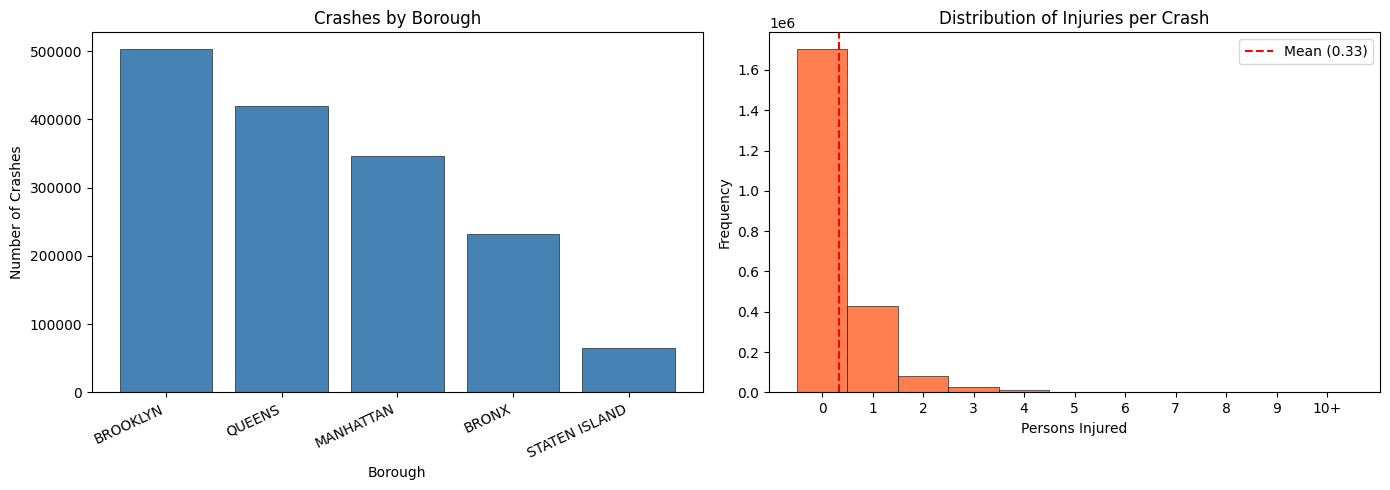

In [7]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

borough_counts = df['BOROUGH'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(borough_counts)), borough_counts.values, color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].set_xticks(range(len(borough_counts)))
axes[0].set_xticklabels(borough_counts.index, rotation=25, ha='right')
axes[0].set_xlabel("Borough")
axes[0].set_ylabel("Number of Crashes")
axes[0].set_title("Crashes by Borough")

inj = df['NUMBER OF PERSONS INJURED']
inj_capped = inj.clip(upper=10)
axes[1].hist(inj_capped, bins=np.arange(12) - 0.5, color='coral', edgecolor='black', linewidth=0.4)
axes[1].axvline(inj.mean(), color='red', linestyle='--', label=f'Mean ({inj.mean():.2f})')
axes[1].set_xlabel("Persons Injured")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Injuries per Crash")
axes[1].set_xticks(range(11))
axes[1].set_xticklabels([str(i) if i < 10 else '10+' for i in range(11)])
axes[1].legend()

plt.tight_layout()
plt.show()

2. Outlier Detection: The injury distribution is heavily right skewed with extreme outliers, including crashes involving more than 40 injured individuals. These outliers likely represent rare, high impact events and can disproportionately affect statistical measures such as the mean. Therefore, robust statistics or transformations may be necessary for accurate modeling.

/var/folders/dz/3wqr_ksx4j537_x4qnv31wh00000gn/T/ipykernel_17669/4275201060.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(borough_data, labels=boroughs, showfliers=True,


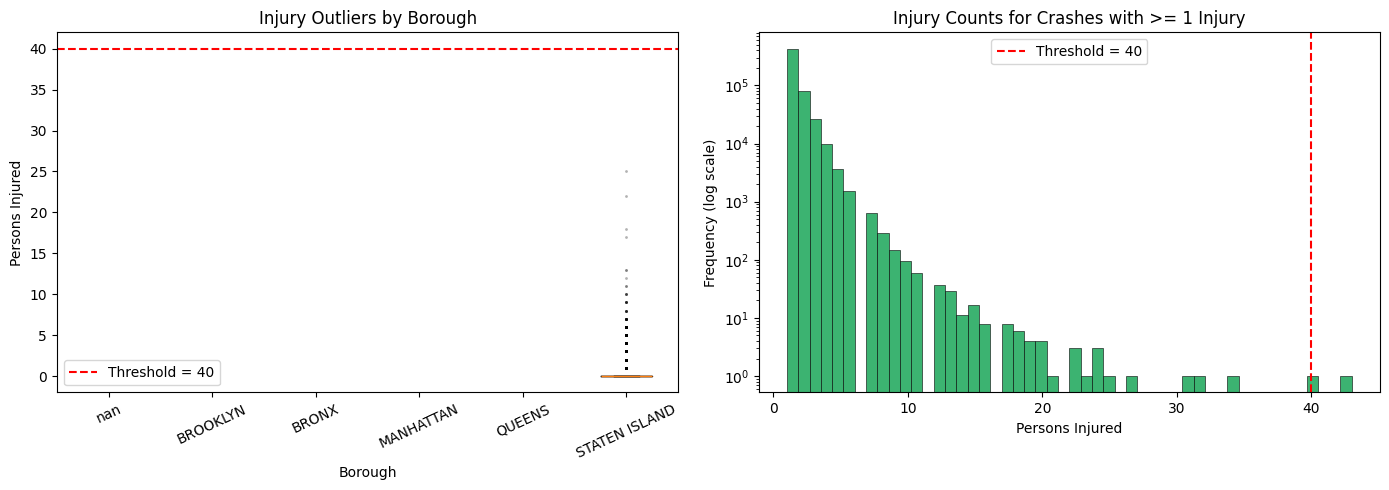

In [8]:
inj = df['NUMBER OF PERSONS INJURED']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

boroughs = df['BOROUGH'].unique()
borough_data = [df.loc[df['BOROUGH'] == b, 'NUMBER OF PERSONS INJURED'].values for b in boroughs]
bp = axes[0].boxplot(borough_data, labels=boroughs, showfliers=True,
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].axhline(y=40, color='red', linestyle='--', label='Threshold = 40')
axes[0].set_xlabel("Borough")
axes[0].set_ylabel("Persons Injured")
axes[0].set_title("Injury Outliers by Borough")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=25)

injured_only = inj[inj > 0]
axes[1].hist(injured_only, bins=50, color='mediumseagreen', edgecolor='black', linewidth=0.4)
axes[1].axvline(x=40, color='red', linestyle='--', label='Threshold = 40')
axes[1].set_yscale('log')
axes[1].set_xlabel("Persons Injured")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_title("Injury Counts for Crashes with >= 1 Injury")
axes[1].legend()

plt.tight_layout()
plt.show()

3. Hypothesis Testing: With a two sample t test comparing nighttime and daytime crashes yields a statistically significant result (p < 0.001), indicating that nighttime crashes result in a higher number of injuries on average. This suggests that reduced visibility and nighttime driving conditions contribute to increased crash severity.

t-statistic: nan, p-value: nan


/var/folders/dz/3wqr_ksx4j537_x4qnv31wh00000gn/T/ipykernel_17669/3071911040.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([night_inj, day_inj], labels=['Nighttime', 'Daytime'],


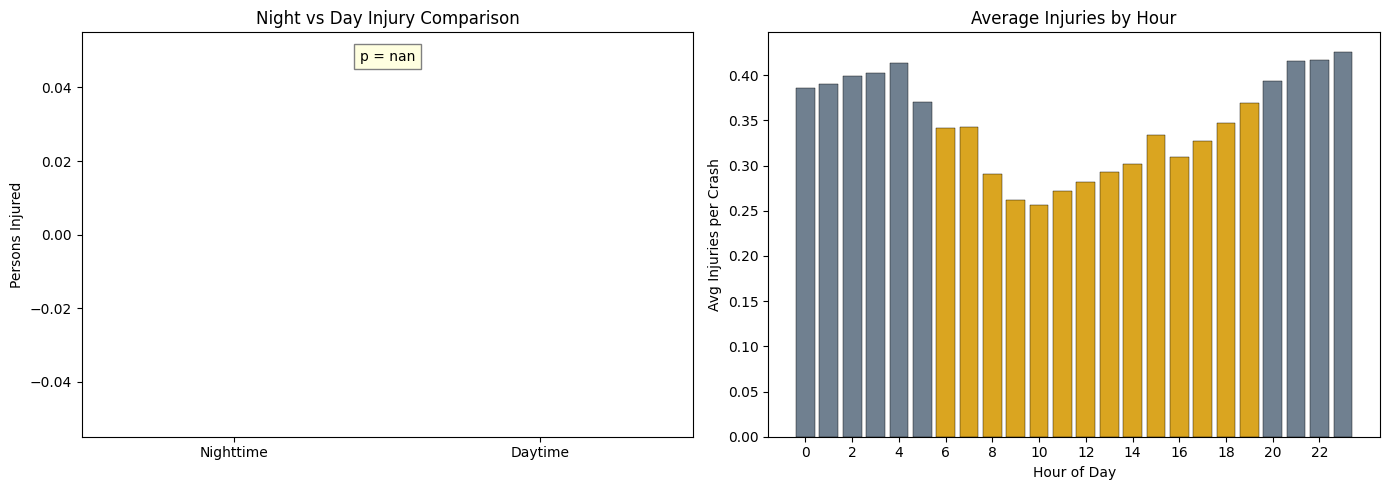

In [9]:
from scipy import stats

hour = df['CRASH TIME'].dt.hour
night_mask = (hour >= 20) | (hour < 6)
night_inj = df.loc[night_mask, 'NUMBER OF PERSONS INJURED'].values
day_inj = df.loc[~night_mask, 'NUMBER OF PERSONS INJURED'].values

t_stat, p_val = stats.ttest_ind(night_inj, day_inj, equal_var=False)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot([night_inj, day_inj], labels=['Nighttime', 'Daytime'],
                     showfliers=False, patch_artist=True)
bp['boxes'][0].set_facecolor('slategray')
bp['boxes'][1].set_facecolor('goldenrod')
axes[0].set_ylabel("Persons Injured")
axes[0].set_title("Night vs Day Injury Comparison")
axes[0].text(0.5, 0.93, f"p = {p_val:.2e}", transform=axes[0].transAxes,
             ha='center', fontsize=10, bbox=dict(facecolor='lightyellow', edgecolor='gray'))

hourly_avg = df.groupby(hour)['NUMBER OF PERSONS INJURED'].mean()
bar_colors = ['slategray' if (h >= 20 or h < 6) else 'goldenrod' for h in hourly_avg.index]
axes[1].bar(hourly_avg.index, hourly_avg.values, color=bar_colors, edgecolor='black', linewidth=0.3)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Avg Injuries per Crash")
axes[1].set_title("Average Injuries by Hour")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()